### PuTTY log 2023.06.30 14:27:45 prozor C-11
Sunčano, dimljaci, pračenje, 29.80 inHg, 44% humidity

In [5]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from astropy.io import ascii

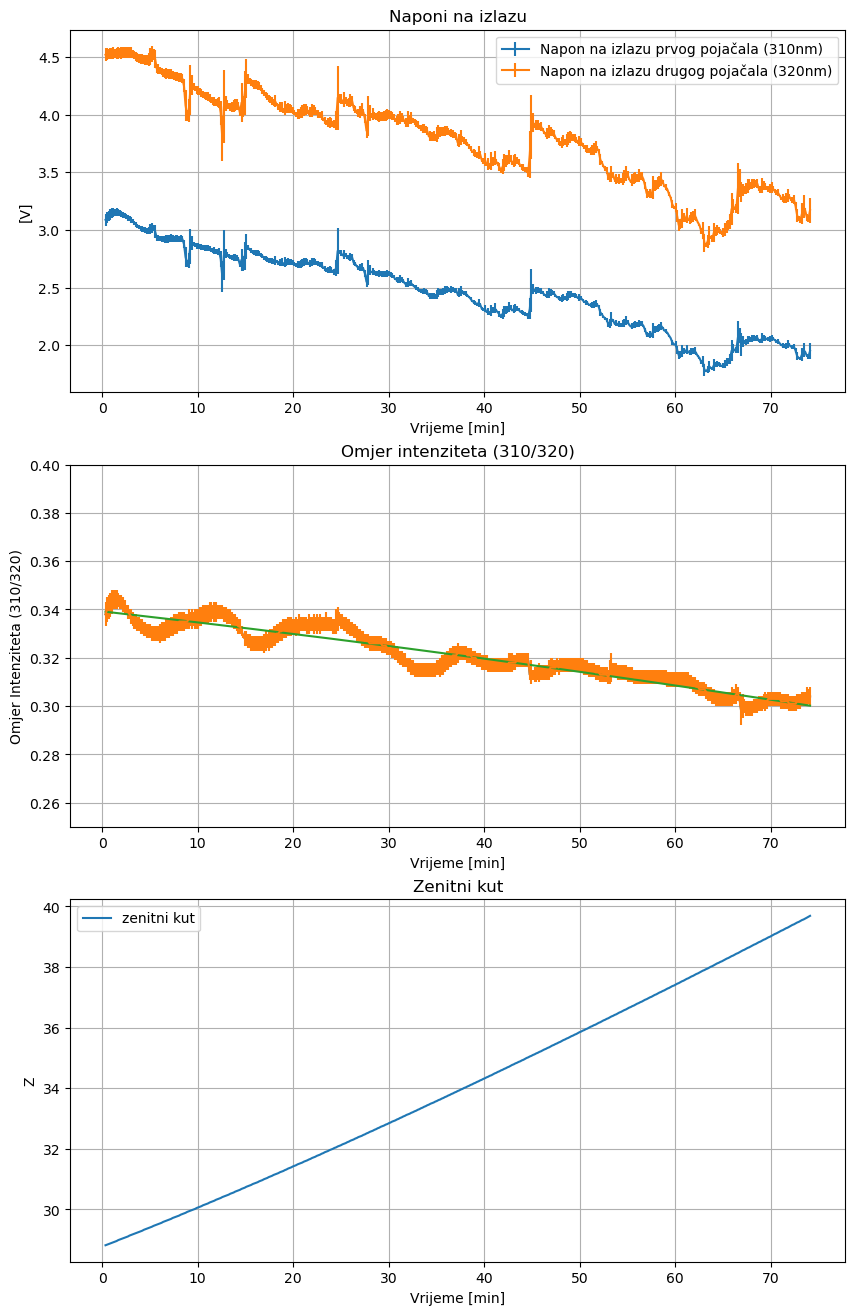

In [6]:
i, meanV1, meanV2, meanRatio, stdV1, stdV2, stdRatio, el = np.loadtxt('ozone_3006_1.csv', delimiter=",",
                                                                  dtype = 'float', unpack=True,skiprows=4)
window = int(len(meanRatio))
avgRatio = scipy.signal.savgol_filter(meanRatio, window,2)
lnRatio = -100*np.log10(np.e)*np.log(avgRatio)
fig, ax = plt.subplots(3,1,figsize=(10,16))
ax[0].errorbar(i/60, meanV1,stdV1, linestyle='-',label='Napon na izlazu prvog pojačala (310nm)')
ax[0].errorbar(i/60, meanV2,stdV2, linestyle='-',label='Napon na izlazu drugog pojačala (320nm)')
ax[0].set(xlabel='Vrijeme [min]', ylabel='[V]',title='Naponi na izlazu')
ax[0].grid()
ax[0].legend(loc='best')
ax[1].plot(i/60, meanRatio, linestyle='-')
ax[1].errorbar(i/60,meanRatio,stdRatio)
ax[1].plot(i/60, avgRatio, linestyle='-')
ax[1].set(xlabel='Vrijeme [min]', ylabel='Omjer Intenziteta (310/320)',title='Omjer intenziteta (310/320)',ylim=(0.25,0.4))
ax[1].grid()
ax[2].plot(i/60, 90-el, linestyle='-', label='zenitni kut')
ax[2].set(xlabel='Vrijeme [min]', ylabel='Z',title='Zenitni kut')
ax[2].grid()
ax[2].legend(loc='best')
plt.show()
plt.close(fig)

In [7]:
np.cos(np.deg2rad(el[0]-el[len(el)-1])), np.log(1/meanRatio[0]), np.log(1/meanRatio[len(meanRatio)-1])

(0.9820575882295652, 1.0847093834991184, 1.1907275775759154)

In [24]:
np.cos(np.deg2rad(el[0]-el[len(el)-1])), meanRatio[0]-meanRatio[len(meanRatio)-1]

(0.9820575882295652, 0.03400000000000003)